In [3]:
!pip install pandas matplotlib seaborn scikit-learn xgboost lightgbm catboost jupyterlab scipy


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


Dataset Shape: (569, 30)

First few rows:
   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst radius  wors

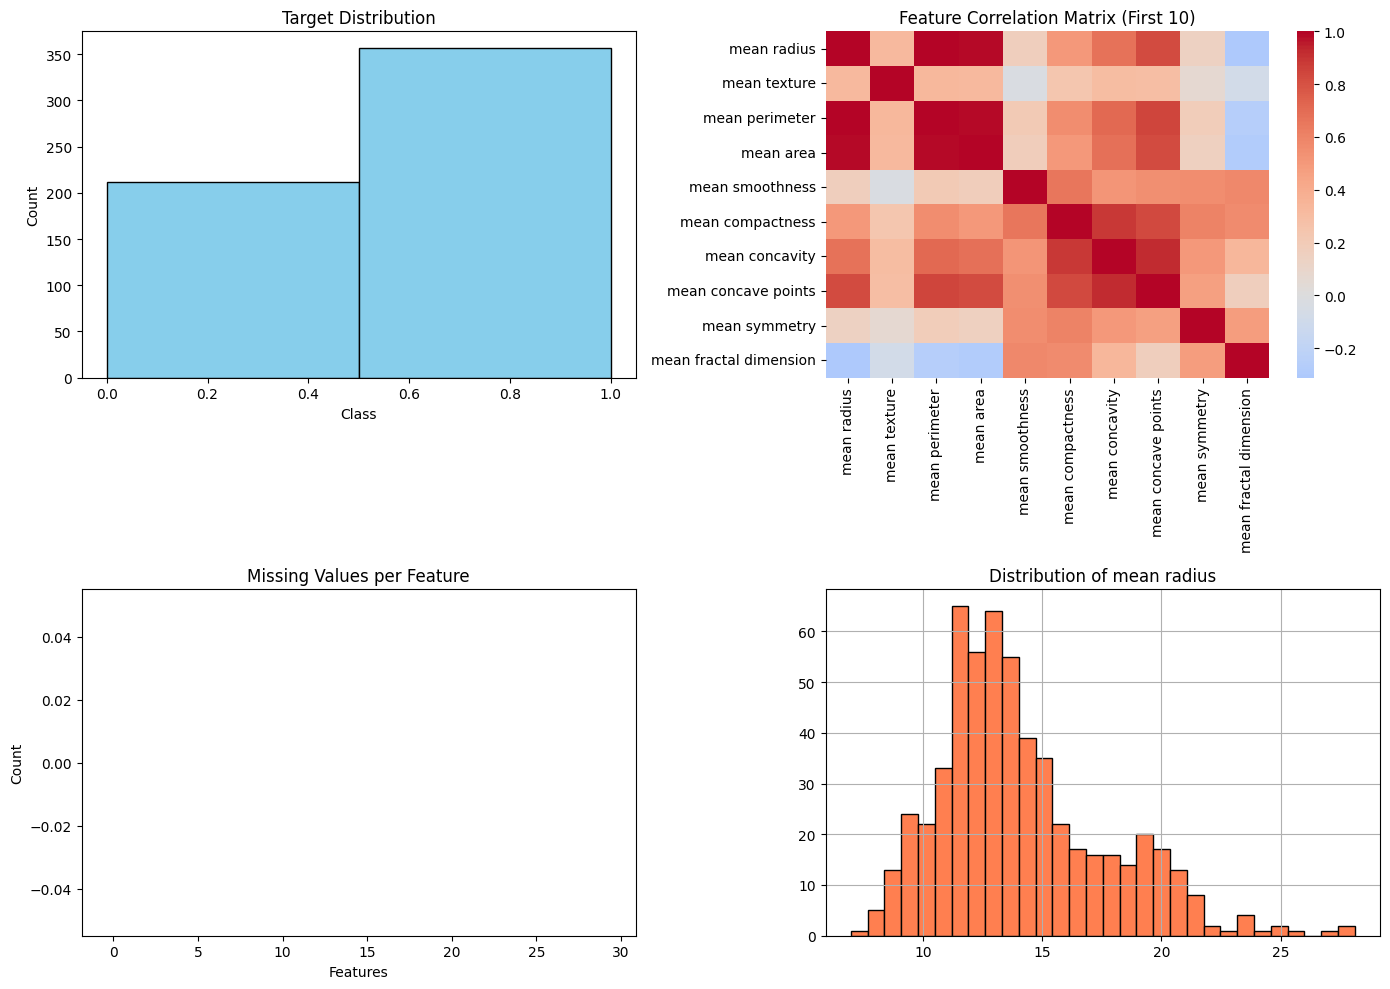


XGBOOST MODEL

Accuracy: 0.9649
ROC-AUC Score: 0.9957

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.93      0.95        42
           1       0.96      0.99      0.97        72

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



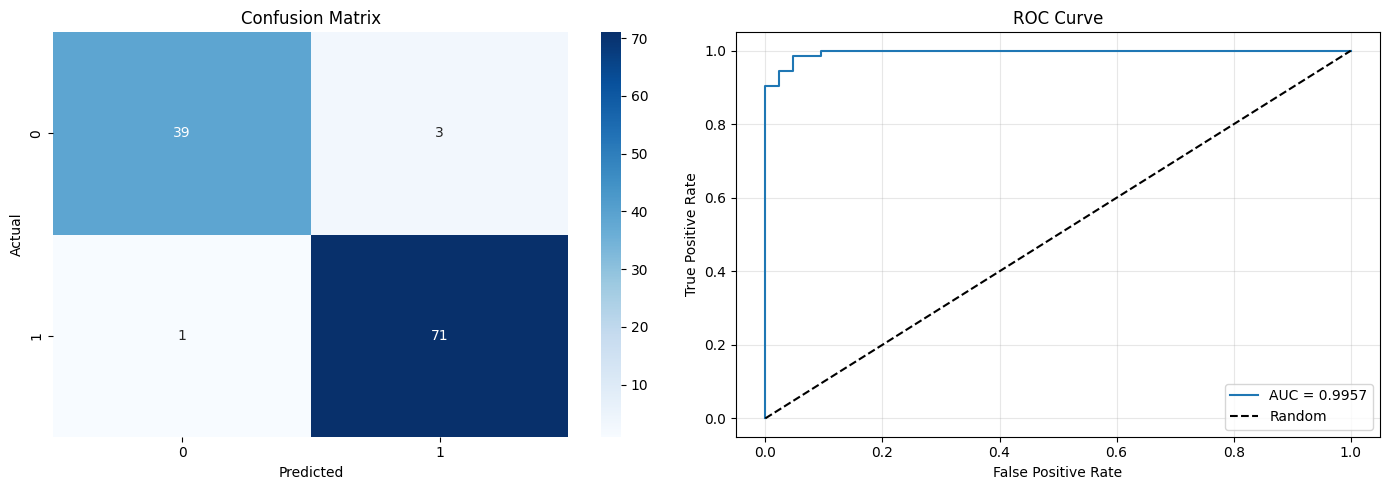

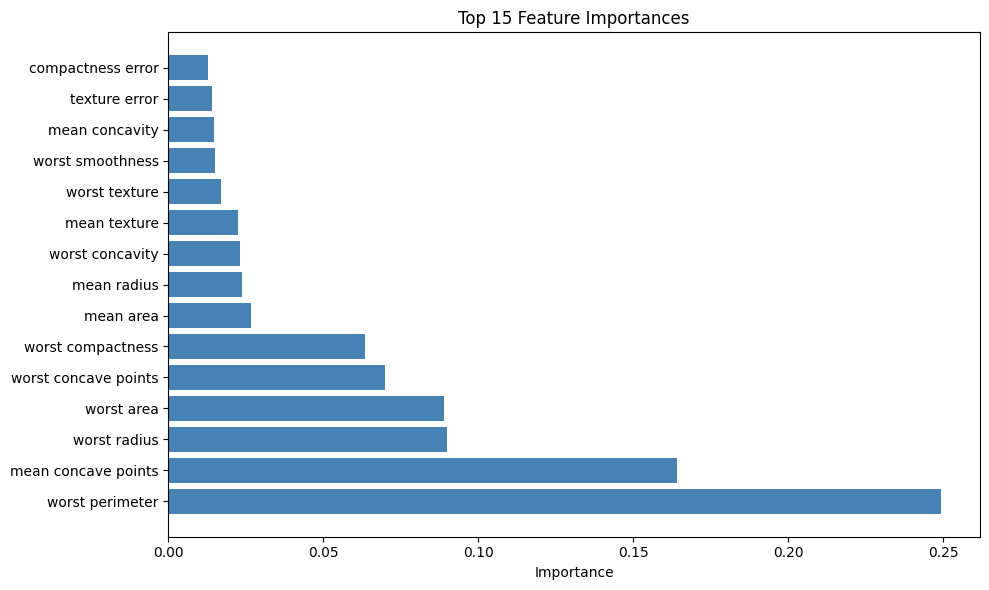

In [ ]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

# Load dataset from sklearn
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name='target')

print("Dataset Shape:", X.shape)
print("\nFirst few rows:")
print(X.head())

# EDA
print("\n" + "="*50)
print("EXPLORATORY DATA ANALYSIS")
print("="*50)

print("\nDataset Info:")
print(f"Features: {X.shape[1]}, Samples: {X.shape[0]}")
print(f"Missing values: {X.isnull().sum().sum()}")
print(f"\nTarget distribution:\n{y.value_counts()}")

# Statistical summary
print("\nStatistical Summary:")
print(X.describe())

# Visualizations
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Target distribution
axes[0, 0].hist(y, bins=2, edgecolor='black', color='skyblue')
axes[0, 0].set_title('Target Distribution')
axes[0, 0].set_xlabel('Class')
axes[0, 0].set_ylabel('Count')

# Feature correlations
corr_matrix = X.corr()
sns.heatmap(corr_matrix.iloc[:10, :10], ax=axes[0, 1], cmap='coolwarm', center=0)
axes[0, 1].set_title('Feature Correlation Matrix (First 10)')

# Missing values
axes[1, 0].bar(range(len(X.columns)), X.isnull().sum().values)
axes[1, 0].set_title('Missing Values per Feature')
axes[1, 0].set_xlabel('Features')
axes[1, 0].set_ylabel('Count')

# Feature distributions (sample)
X[X.columns[0]].hist(ax=axes[1, 1], bins=30, edgecolor='black', color='coral')
axes[1, 1].set_title(f'Distribution of {X.columns[0]}')

plt.tight_layout()
plt.show()

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("\n" + "="*50)
print("XGBOOST MODEL")
print("="*50)

# Train XGBoost
xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss'
)

xgb_model.fit(X_train, y_train, verbose=False)

# Predictions
y_pred = xgb_model.predict(X_test)
y_pred_proba = xgb_model.predict_proba(X_test)[:, 1]

# Model evaluation
print(f"\nAccuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_pred_proba):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Visualizations
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Confusion Matrix')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
axes[1].plot(fpr, tpr, label=f'AUC = {roc_auc_score(y_test, y_pred_proba):.4f}')
axes[1].plot([0, 1], [0, 1], 'k--', label='Random')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Feature importance
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': xgb_model.feature_importances_
}).sort_values('Importance', ascending=False).head(15)

plt.figure(figsize=(10, 6))
plt.barh(feature_importance['Feature'], feature_importance['Importance'], color='steelblue')
plt.xlabel('Importance')
plt.title('Top 15 Feature Importances')
plt.tight_layout()
plt.show()

In [14]:
from sklearn.datasets import load_breast_cancer
from sklearn.cluster import DBSCAN
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
data = load_breast_cancer()

X = data.data
y = pd.Series(data.target)

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

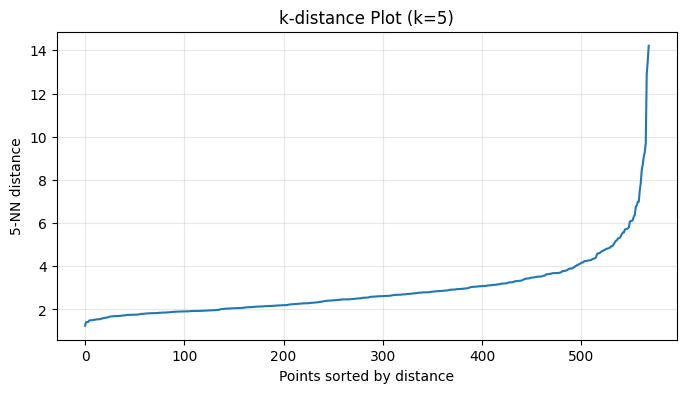

Selected eps (90th percentile): 4.3247
Number of clusters found (excluding noise): 1
Noise points: 38 / 569


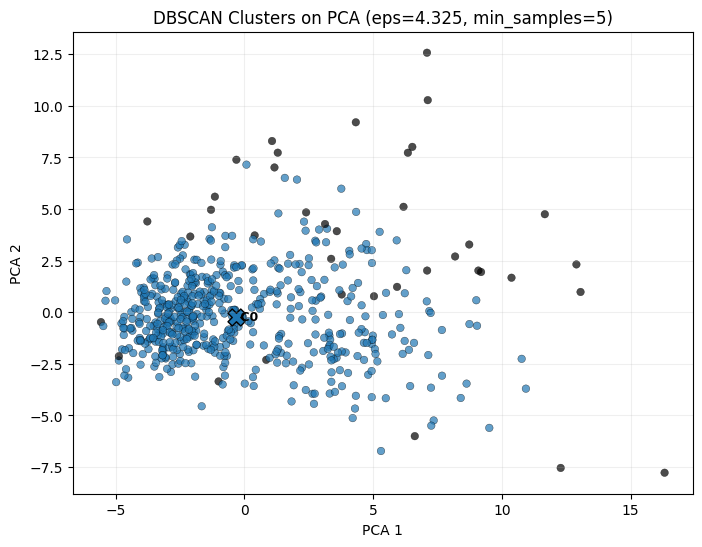


Cluster vs Target counts:
target     0    1
cluster          
-1        23   15
 0       189  342


In [15]:
from sklearn.cluster import DBSCAN
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# DBSCAN clustering and visualizations on the existing breast cancer dataset (X, y)

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# k-distance plot to help choose eps
nn = NearestNeighbors(n_neighbors=5)
nn.fit(X_scaled)

distances, _ = nn.kneighbors(X_scaled)
kdistances = np.sort(distances[:, -1])

plt.figure(figsize=(8, 4))
plt.plot(kdistances)
plt.xlabel('Points sorted by distance')
plt.ylabel('5-NN distance')
plt.title('k-distance Plot (k=5)')
plt.grid(alpha=0.3)
plt.show()

# Heuristic eps: use the 90th percentile of 5-NN distances
eps = float(np.percentile(kdistances, 90))
print(f"Selected eps (90th percentile): {eps:.4f}")

# Run DBSCAN
db = DBSCAN(eps=eps, min_samples=5, metric='euclidean')
labels = db.fit_predict(X_scaled)

# Summary
n_noise = np.sum(labels == -1)
unique_labels = np.unique(labels)
n_clusters = len(unique_labels[unique_labels != -1])

print(f"Number of clusters found (excluding noise): {n_clusters}")
print(f"Noise points: {n_noise} / {X.shape[0]}")

# Compute silhouette score if applicable
if n_clusters > 1:
    sil = silhouette_score(X_scaled[labels != -1], labels[labels != -1])
    print(f"Silhouette score (excluding noise): {sil:.4f}")

# 2D visualization using PCA
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))

palette = sns.color_palette("tab10", n_colors=max(1, n_clusters))

# Map labels to colors (noise -> black)
colors = [
    ("black" if lab == -1 else palette[int(lab) % len(palette)])
    for lab in labels
]

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=colors,
    s=30,
    alpha=0.7,
    edgecolor='k',
    linewidth=0.3
)

# Annotate cluster centers in PCA space
for lab in unique_labels:
    if lab == -1:
        continue

    mask = labels == lab
    cx, cy = X_pca[mask].mean(axis=0)

    plt.scatter(
        cx,
        cy,
        marker='X',
        s=150,
        c=[palette[int(lab) % len(palette)]],
        edgecolor='k'
    )

    plt.text(
        cx,
        cy,
        f" C{lab}",
        fontsize=9,
        weight='bold',
        va='center'
    )

plt.title(f"DBSCAN Clusters on PCA (eps={eps:.3f}, min_samples=5)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.grid(alpha=0.2)
plt.show()

# Compare clusters vs original target distribution
cluster_counts = pd.crosstab(
    pd.Series(labels, name='cluster'),
    y.rename('target')
)

print("\nCluster vs Target counts:")
print(cluster_counts)